In [3]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import altair as alt
import hvplot.pandas
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


RAW_DATA_DIR = Path("../data/raw")
REGIONAL_PHENOMETRICS_FILE = RAW_DATA_DIR / "PA_MD_DE_NJ_phenometrics.csv"

In [5]:
# Pull counties from census
counties_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
counties = gpd.read_file(counties_url)






In [7]:
# Get target states (10=DE, 24=MD, 34=NJ, 42=PA)
target_states = ['10', '24', '34', '42']
regional_counties = counties[counties["STATEFP"].isin(target_states)]
pa_keep = ['Philadelphia', 'Bucks', 'Montgomery', 'Chester', 'Delaware']
md_drop = ['Garrett', 'Allegany', 'Washington']
nj_drop = ['Sussex', 'Warren']
climate_counties = regional_counties[
    ((regional_counties['STATEFP'] == '42') & (regional_counties['NAME'].isin(pa_keep))) |
    ((regional_counties['STATEFP'] == '24') & (~regional_counties['NAME'].isin(md_drop))) |
    ((regional_counties['STATEFP'] == '34') & (~regional_counties['NAME'].isin(nj_drop))) |
    (regional_counties['STATEFP'] == '10') 
]
# Standardize CRS
climate_counties = climate_counties.to_crs("EPSG:4326")


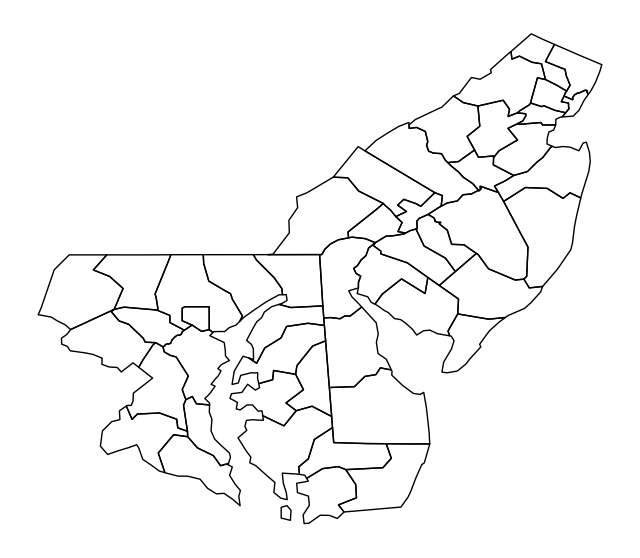

In [ ]:
# Delaware valley plot
fig, ax = plt.subplots(figsize=(8, 8))

ax = climate_counties.plot(ax=ax, facecolor="none", edgecolor="black")

ax.set_axis_off()
ax.set_aspect("equal")

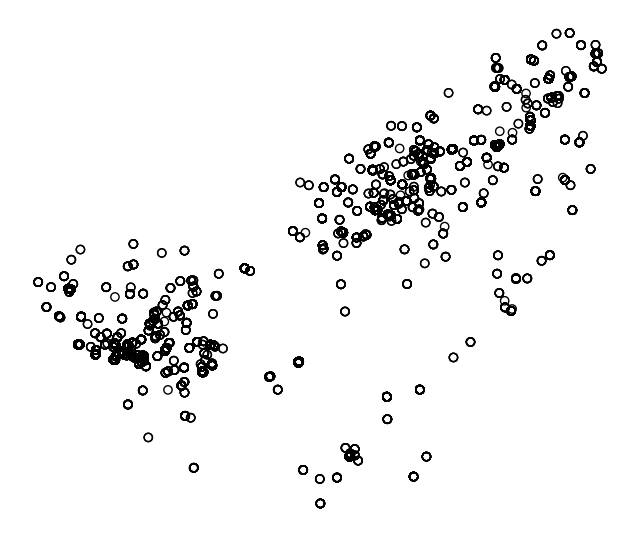

In [ ]:
# Turn massive npn csv into dataframe with point geometry
npn_df = pd.read_csv("/Users/prince/philly-tree-mapper/data/raw/PA_MD_DE_NJ_phenometrics.csv")
npn_gdf = gpd.GeoDataFrame(
    npn_df,
    geometry=gpd.points_from_xy(npn_df.Longitude, npn_df.Latitude),
    crs="EPSG:4326"
)

# Create new geo dataframe with trees only in the proper climate counties
climate_matched_npn = gpd.sjoin(npn_gdf, climate_counties, how="inner", predicate="intersects")
climate_matched_npn
# Plot the where the trees are inside of the delaware valley region
fig, ax = plt.subplots(figsize=(8, 8))

ax = climate_matched_npn.plot(ax=ax, facecolor="none", edgecolor="black")

ax.set_axis_off()
ax.set_aspect("equal")

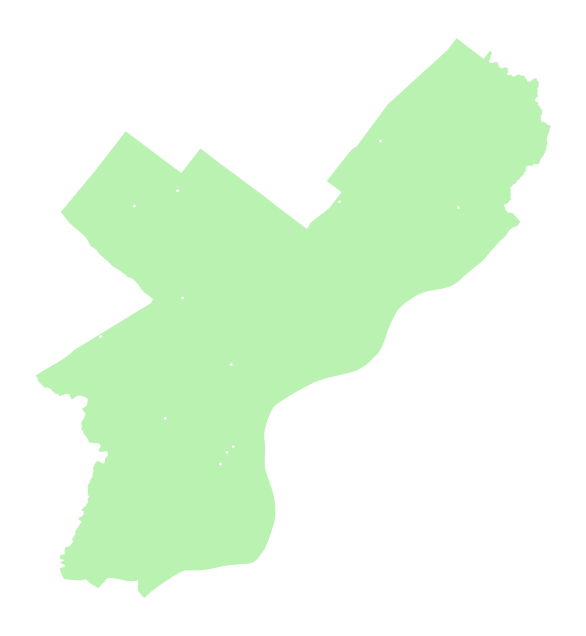

In [ ]:
# Testing out making a map showing where the trees in the climate lie in philly
city_limits = gpd.read_file("/Users/prince/philly-tree-mapper/data/MUSA_City_Limits")
buffered_npn = climate_matched_npn.copy().to_crs(epsg=3857)
buffered_npn["geometry"] = buffered_npn.buffer(100)
fig, ax = plt.subplots(figsize=(8, 8))
diff = gpd.overlay(
    city_limits.to_crs(epsg=3857),
    buffered_npn,
    how="difference",
)

# Plot
diff.plot(facecolor="#b9f2b1", ax=ax)
ax.set_axis_off()
ax.set_aspect("equal")

In [ ]:
common_excluded = ["Platanus"]
check = climate_matched_npn[climate_matched_npn["Genus"].isin(common_excluded)]
check

,Site_ID,Latitude,Longitude,Elevation_in_Meters,State,Species_ID,Genus,Species,Common_Name,Kingdom,...,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
11967,17443,38.967636,-77.119751,97,MD,970,Platanus,occidentalis,American sycamore,Plantae,...,01712500,0500000US24031,24031,Montgomery,Montgomery County,MD,Maryland,06,1277193339,35686502
11968,17443,38.967636,-77.119751,97,MD,970,Platanus,occidentalis,American sycamore,Plantae,...,01712500,0500000US24031,24031,Montgomery,Montgomery County,MD,Maryland,06,1277193339,35686502
11969,17443,38.967636,-77.119751,97,MD,970,Platanus,occidentalis,American sycamore,Plantae,...,01712500,0500000US24031,24031,Montgomery,Montgomery County,MD,Maryland,06,1277193339,35686502
12474,18813,40.320068,-75.102783,94,PA,970,Platanus,occidentalis,American sycamore,Plantae,...,01209173,0500000US42017,42017,Bucks,Bucks County,PA,Pennsylvania,06,1565303838,45293815
12475,18813,40.320068,-75.102783,94,PA,970,Platanus,occidentalis,American sycamore,Plantae,...,01209173,0500000US42017,42017,Bucks,Bucks County,PA,Pennsylvania,06,1565303838,45293815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111531,54322,40.314819,-75.022743,90,PA,970,Platanus,occidentalis,American sycamore,Plantae,...,01209173,0500000US42017,42017,Bucks,Bucks County,PA,Pennsylvania,06,1565303838,45293815
111532,54322,40.314819,-75.022743,90,PA,970,Platanus,occidentalis,American sycamore,Plantae,...,01209173,0500000US42017,42017,Bucks,Bucks County,PA,Pennsylvania,06,1565303838,45293815
111533,54322,40.314819,-75.022743,90,PA,970,Platanus,occidentalis,American sycamore,Plantae,...,01209173,0500000US42017,42017,Bucks,Bucks County,PA,Pennsylvania,06,1565303838,45293815
129370,57350,40.165665,-75.192650,106,-9999,970,Platanus,occidentalis,American sycamore,Plantae,...,01213680,0500000US42091,42091,Montgomery,Montgomery County,PA,Pennsylvania,06,1250888984,10983029


In [ ]:
%store -r clean_trees

In [ ]:
# Create scientific name column in new npn data
climate_matched_npn["scientific_name"] = climate_matched_npn["Genus"] + " " + climate_matched_npn["Species"]
climate_matched_npn

,Site_ID,Latitude,Longitude,Elevation_in_Meters,State,Species_ID,Genus,Species,Common_Name,Kingdom,...,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,scientific_name
4,418,38.888126,-76.553368,24,MD,35,Syringa,chinensis,Red Rothomagensis lilac,Plantae,...,0500000US24003,24003,Anne Arundel,Anne Arundel County,MD,Maryland,06,1074353889,448032843,Syringa chinensis
5,418,38.888126,-76.553368,24,MD,35,Syringa,chinensis,Red Rothomagensis lilac,Plantae,...,0500000US24003,24003,Anne Arundel,Anne Arundel County,MD,Maryland,06,1074353889,448032843,Syringa chinensis
6,418,38.888126,-76.553368,24,MD,35,Syringa,chinensis,Red Rothomagensis lilac,Plantae,...,0500000US24003,24003,Anne Arundel,Anne Arundel County,MD,Maryland,06,1074353889,448032843,Syringa chinensis
7,418,38.888126,-76.553368,24,MD,35,Syringa,chinensis,Red Rothomagensis lilac,Plantae,...,0500000US24003,24003,Anne Arundel,Anne Arundel County,MD,Maryland,06,1074353889,448032843,Syringa chinensis
8,418,38.888126,-76.553368,24,MD,35,Syringa,chinensis,Red Rothomagensis lilac,Plantae,...,0500000US24003,24003,Anne Arundel,Anne Arundel County,MD,Maryland,06,1074353889,448032843,Syringa chinensis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135407,56856,40.052708,-75.687523,134,PA,1431,Amelanchier,arborea,common serviceberry,Plantae,...,0500000US42029,42029,Chester,Chester County,PA,Pennsylvania,06,1943905797,22412288,Amelanchier arborea
135408,56856,40.052708,-75.687523,134,PA,1431,Amelanchier,arborea,common serviceberry,Plantae,...,0500000US42029,42029,Chester,Chester County,PA,Pennsylvania,06,1943905797,22412288,Amelanchier arborea
135430,59544,38.996899,-77.112534,-9999,MD,195,Asclepias,tuberosa,butterfly milkweed,Plantae,...,0500000US24031,24031,Montgomery,Montgomery County,MD,Maryland,06,1277193339,35686502,Asclepias tuberosa
135431,59544,38.996899,-77.112534,-9999,MD,195,Asclepias,tuberosa,butterfly milkweed,Plantae,...,0500000US24031,24031,Montgomery,Montgomery County,MD,Maryland,06,1277193339,35686502,Asclepias tuberosa


In [ ]:
# find matches among philly data and npn
philly_npn_s_name_match = clean_trees[clean_trees["scientific_name"].isin(climate_matched_npn["scientific_name"])]
percent_sname_match = len(philly_npn_s_name_match) / len(clean_trees)
print(percent_sname_match)

0.5255766300985277


52% exact matched in this dataset. Better than before but marginally

In [ ]:
philly_npn_genus_match = clean_trees[clean_trees["Genus"].isin(climate_matched_npn["Genus"])]
percent_genus_match = len(philly_npn_genus_match) / len(clean_trees)
print(percent_genus_match)

0.9472899882245714


94% genus match by drawing new dataset. honestly not terrible.

In [ ]:
# looking into genus misses
philly_genus_misses = clean_trees[~clean_trees["Genus"].isin(climate_matched_npn["Genus"])]
genus_miss_count = philly_genus_misses["scientific_name"].value_counts().reset_index().set_index("scientific_name")
genus_miss_count

,count
scientific_name,
Sophora japonica,1833
Maackia amurensis,1031
Koelreuteria paniculata,907
Lagerstroemia indica,444
Ostrya virginiana,442
Catalpa speciosa,352
Cercidiphyllum japonicum,339
,297
Shrub shrub,241
